# Prompt 4C - Final Selection and Pre-IID Freeze

This notebook uses saved artifacts only. It fits no model and opens no Raw or IID data.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display
ROOT=Path('..').resolve()
REPORTS=ROOT/'outputs/reports'
FIGURES=ROOT/'outputs/figures/prompt4c'

## 1. Development research is closed

Prompt 4C does not search for a better model. All Development research is closed. No Candidate reached a six-of-six breakthrough.

In [2]:
freeze=json.loads((REPORTS/'prompt4c_final_selection_freeze.json').read_text()); display(pd.DataFrame([{'status':freeze['status'],'research_closed':freeze['development_research_closed'],'primary':freeze['final_primary_recipe'],'comparator':freeze['simple_comparator']}]))

,status,research_closed,primary,comparator
0,FROZEN,True,stage3_residual_t75_a75,ens_boost_cat060


## 2. Final model choice

Stage 3 is the final Primary. It gives a conservative Body and Tail balance. Block A had a slightly lower Development MAE, but its Body result was worse and its MAE advantage was not clearly separated from Stage 3.

In [3]:
metrics=pd.read_csv(REPORTS/'prompt4c_historical_metric_extension.csv'); display(metrics[['model_id','role','mae','rmse','bottom_90_mae','top_decile_mae','mape_percent','wape_percent']].round(4))

,model_id,role,mae,rmse,bottom_90_mae,top_decile_mae,mape_percent,wape_percent
0,ens_boost_cat060,simple comparator,62.3563,125.4182,47.5770,195.1786,34.3050,25.0592
1,stage3_residual_t75_a75,final Primary,62.1967,123.0385,47.6690,192.7569,34.3385,24.9950
2,nf_global2_oldraw_direct_cap25,historical MAE challenger,62.1147,124.4339,47.9698,189.2354,33.8606,24.9621
3,prompt4b3__beat_costaware,Development-only diagnostic,62.3388,125.3265,47.5773,195.0003,34.3043,25.0521
4,prompt4b4__sub_ldslgb,Development-only diagnostic,63.1328,123.3884,49.4257,186.3188,35.4913,25.3712
5,prompt4b4__sub_densecat,Development-only diagnostic,62.4831,125.2475,47.7446,194.9389,34.3294,25.1101


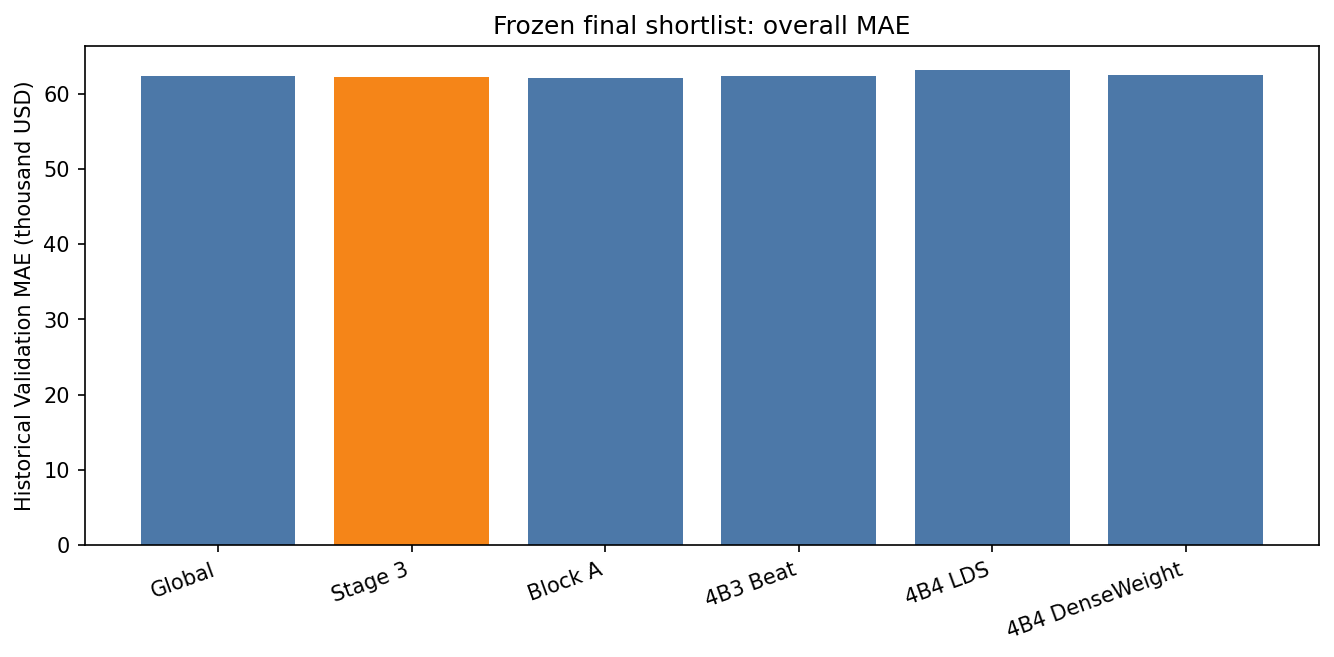

In [4]:
display(Image(filename=str(FIGURES/'01_final_shortlist_mae.png')))

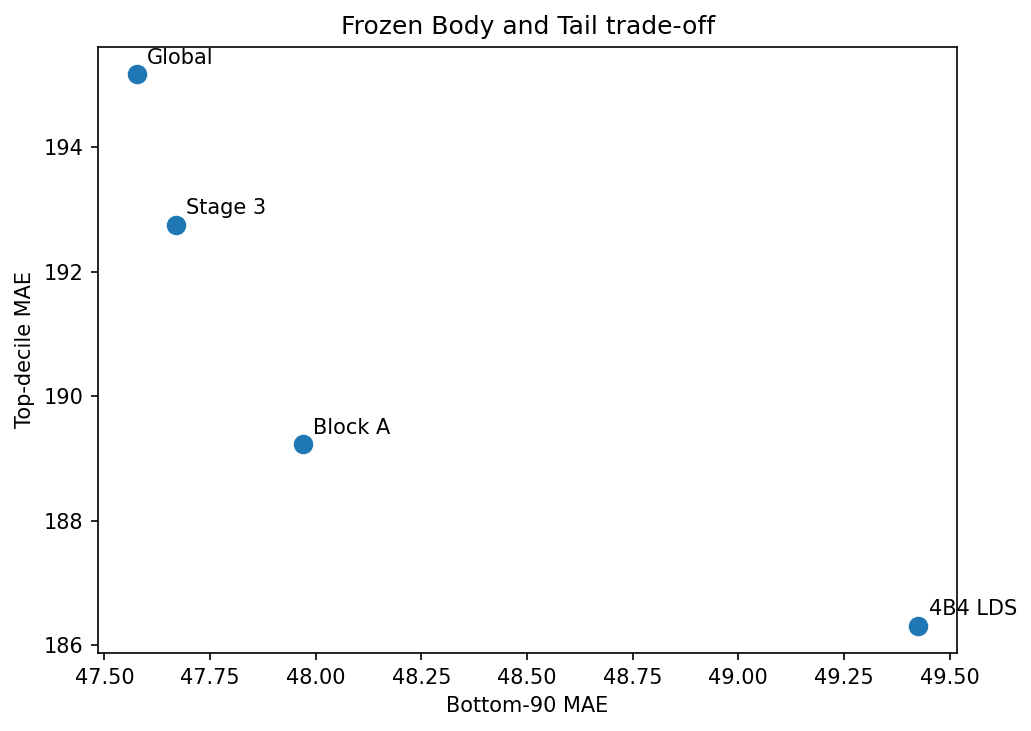

In [5]:
display(Image(filename=str(FIGURES/'02_bottom90_topdecile_pareto.png')))

## 3. Percentage errors are secondary

MAPE and WAPE help interpretation. They did not select the model and cannot change the Primary. The decile analysis separates absolute error from percentage error.

In [6]:
deciles=pd.read_csv(REPORTS/'prompt4c_historical_decile_metrics.csv'); display(deciles.loc[deciles.model_id.isin(['ens_boost_cat060','stage3_residual_t75_a75','nf_global2_oldraw_direct_cap25'])].head(15).round(4))

,model_id,decile,decile_index,row_count,target_min,target_max,mean_target,median_target,mean_prediction,median_prediction,mae,mape_percent,wape_percent,rmse,mean_signed_error,underprediction_rate
0,ens_boost_cat060,D1,1,10292,1.0,70.0,35.6927,35.0,60.3152,48.5192,29.6046,111.2861,82.9430,48.7453,24.6225,0.2573
1,ens_boost_cat060,D2,2,9821,71.0,110.0,91.8832,93.0,126.3601,116.7492,42.6869,47.2130,46.4578,63.0009,34.4769,0.2270
2,ens_boost_cat060,D3,3,9894,111.0,141.0,126.4552,127.0,151.1500,140.9386,38.4693,30.5546,30.4212,57.7553,24.6947,0.3412
3,ens_boost_cat060,D4,4,10108,142.0,171.0,156.3161,156.0,174.5175,165.1841,38.9348,24.9780,24.9077,62.3135,18.2014,0.4104
4,ens_boost_cat060,D5,5,9993,172.0,202.0,186.9103,187.0,199.0302,188.8178,41.6204,22.2435,22.2676,61.8447,12.1199,0.4796
5,ens_boost_cat060,D6,6,9953,203.0,239.0,220.4595,220.0,221.9791,214.1194,43.7489,19.8640,19.8444,61.1435,1.5196,0.5479
6,ens_boost_cat060,D7,7,9941,240.0,282.0,259.9417,260.0,251.9074,243.2670,51.2448,19.7443,19.7139,71.3166,-8.0342,0.6187
7,ens_boost_cat060,D8,8,10047,283.0,347.0,312.6175,311.0,293.1189,284.7310,61.2068,19.5592,19.5788,80.9035,-19.4986,0.6648
8,ens_boost_cat060,D9,9,9977,348.0,438.0,391.7088,392.0,352.3009,340.6828,81.2935,20.7294,20.7536,107.6343,-39.4079,0.7351
9,ens_boost_cat060,D10,10,9974,439.0,9750.0,710.6120,590.0,571.2431,497.0911,195.5851,24.7735,27.5235,336.5849,-139.3689,0.7942


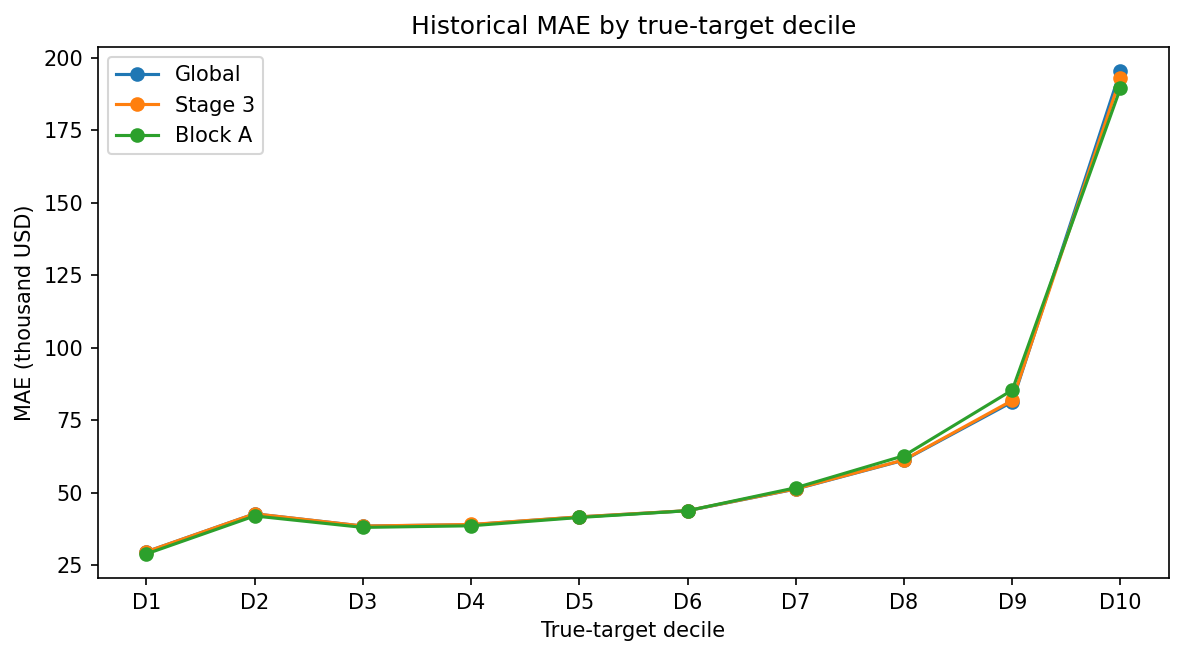

In [7]:
display(Image(filename=str(FIGURES/'03_historical_mae_by_decile.png')))

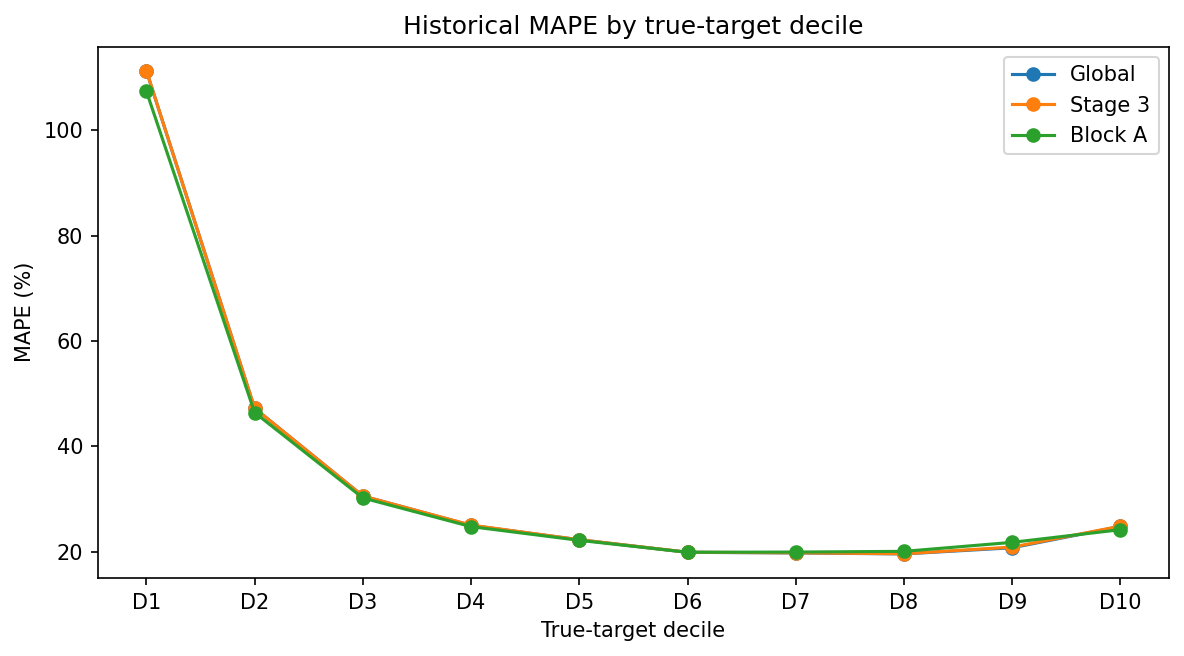

In [8]:
display(Image(filename=str(FIGURES/'04_historical_mape_by_decile.png')))

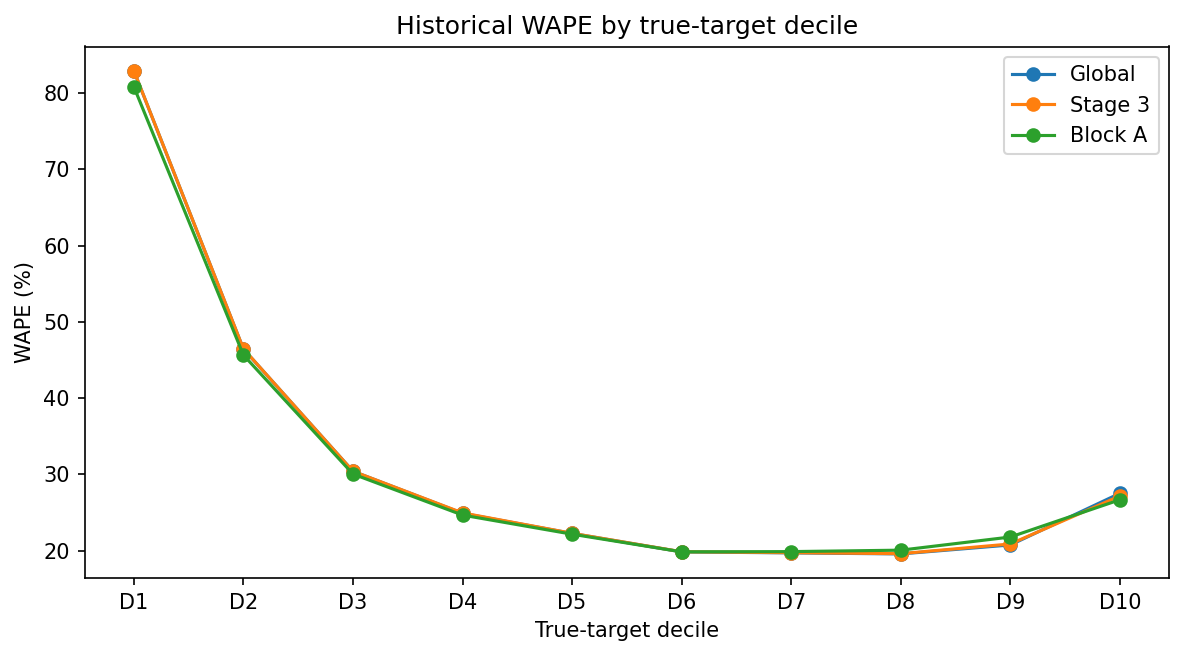

In [9]:
display(Image(filename=str(FIGURES/'05_historical_wape_by_decile.png')))

## 4. Exact historical reconstruction

The saved Global and Stage 3 Validation predictions were reconstructed exactly before final fitting. The Meta-Gate and residual proposal also matched exactly.

In [10]:
g=json.loads((REPORTS/'prompt4c_global_recipe_reproduction.json').read_text()); s=json.loads((REPORTS/'prompt4c_stage3_recipe_reproduction.json').read_text()); display(pd.DataFrame([{'check':'Global','status':g['status'],'max_difference':g['maximum_absolute_prediction_difference']},{'check':'Stage 3','status':s['status'],'max_difference':s['component_maximum_absolute_differences']['final_prediction']}]))

,check,status,max_difference
0,Global,PASS,0.0
1,Stage 3,PASS,0.0


## 5. Leakage-safe final refit

The final meta-targets used two-fold OOF Global predictions. Each Development row was predicted only by models that did not fit that row. The final models then used all 500,000 Development rows.

In [11]:
oof=json.loads((REPORTS/'prompt4c_oof_manifest.json').read_text()); ledger=json.loads((REPORTS/'prompt4c_final_refit_ledger.json').read_text()); display(pd.DataFrame([{'oof_rows':oof['rows'],'self_fit_rows':oof['zero_self_fit_rows'],'refit_roles':ledger['completed_role_count'],'technical_retries':ledger['technical_retry_count']}]))

,oof_rows,self_fit_rows,refit_roles,technical_retries
0,500000,0,11,0


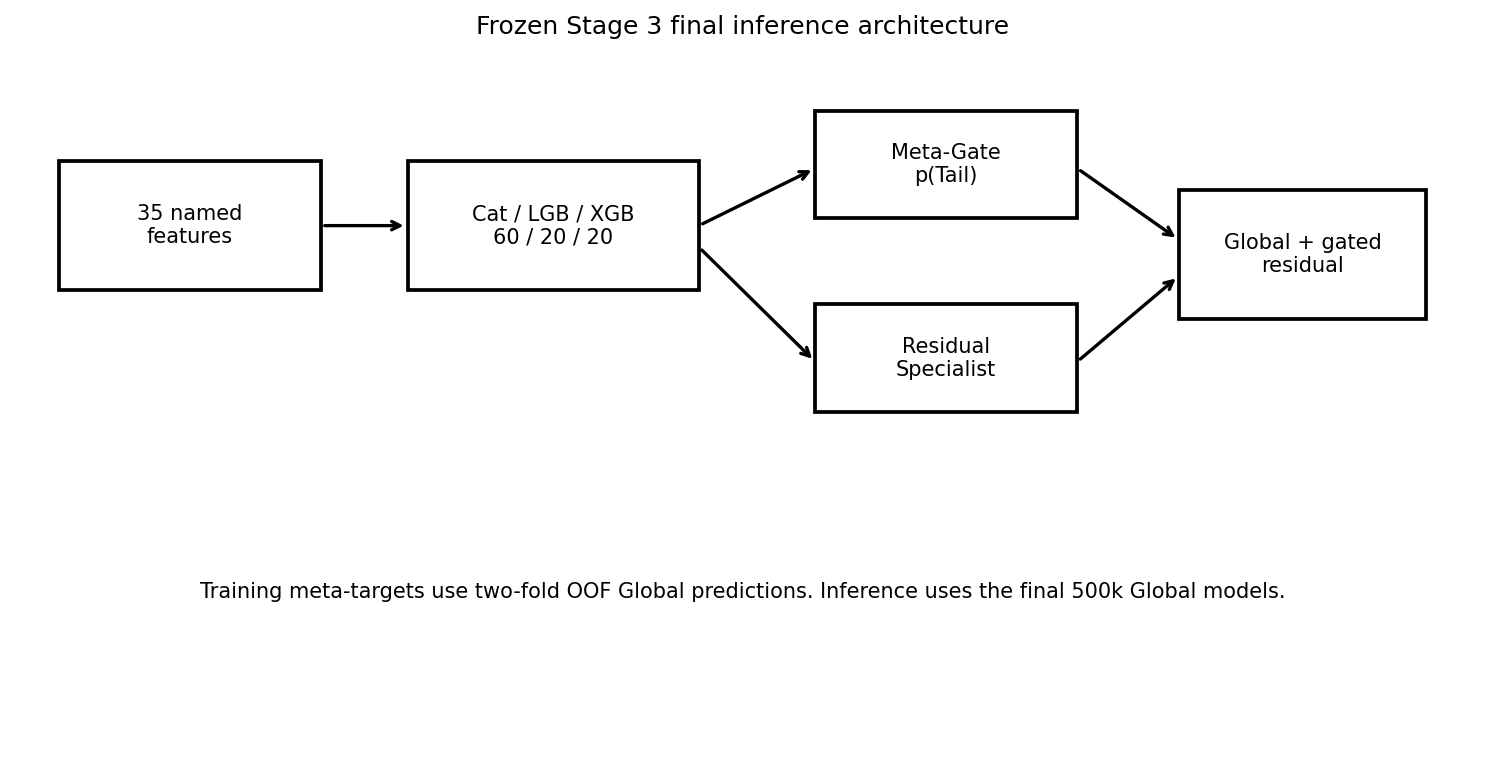

In [12]:
display(Image(filename=str(FIGURES/'06_stage3_inference_architecture.png')))

## 6. Final bundle checks

The Primary and Global bundles use features only. Both pass clean-process reload with exact prediction equality.

In [13]:
reload=json.loads((REPORTS/'prompt4c_bundle_reload.json').read_text()); display(pd.DataFrame(reload['bundles']))

,bundle,path,bundle_sha256,rows,maximum_absolute_difference,required_tolerance,finite,source_frame_unchanged,status
0,primary,outputs/models/final_pre_iid/primary_stage3/bu...,5349ab15fd1c8182ef539f435cc4f065e71ee7da047de0...,1000,0.0,0.0,True,True,PASS
1,global,outputs/models/final_pre_iid/global_comparator...,6f61a0be1fc90d2331b08dada63a453f6c5410d5783f46...,1000,0.0,0.0,True,True,PASS


## 7. IID remains closed

Prompt 4C opened no IID feature or target file and created no IID prediction. Block A is included only when exact zero-fit packaging is possible.

In [14]:
blocka=json.loads((REPORTS/'prompt4c_blocka_package_eligibility.json').read_text()); protocol=json.loads((REPORTS/'prompt4c_prompt5_protocol.json').read_text()); display(pd.DataFrame([{'blocka_iid_eligible':blocka['historical_blocka_iid_eligible'],'raw_access':protocol['raw_access_count'],'iid_feature_access':protocol['iid_feature_access_count'],'iid_target_access':protocol['iid_target_access_count'],'iid_predictions':protocol['iid_prediction_count']}]))

,blocka_iid_eligible,raw_access,iid_feature_access,iid_target_access,iid_predictions
0,False,0,0,0,0


## 8. Prompt 5 is frozen

Prompt 5 may evaluate only the predeclared model set. It uses MAE as Primary, the frozen supporting metrics, two target-band views, and a paired bootstrap. It can never refit or replace the Primary.

In [15]:
display(pd.DataFrame(protocol['protocol']['permitted_models'])); display(pd.DataFrame([protocol['protocol']['bootstrap']]))

,model_id,role,training_rows
0,final_primary_stage3_500k,Primary,500000
1,final_global_500k,simple comparator,500000


,type,resamples,seed,same_rows_within_each_pair,metrics,primary_comparison
0,paired row bootstrap,500,42,True,"[MAE, RMSE, MAPE, WAPE, Bottom-90 MAE, Top-dec...",final Primary minus final Global


## 9. Pre-IID closure

Final Stage 3 and Global were trained on all Development rows and pass clean reload. IID is still unopened. No IID result may change the Primary model.